## **РАЗДЕЛ 1. Первичная обработка и EDA**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

print('Библиотеки успешно импортированы')

Библиотеки успешно импортированы


In [15]:
df = pd.read_csv('BNPL_Financial_Default_Risk_Dataset.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 10000 строк, 11 столбцов


,Customer_ID,Age,Employment_Status,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Late_Payment_History,Shopping_Category_Most_Frequent,Average_Transaction_Value_USD,Default_Risk
0,C00001,29,Employed,73405.0,637.0,2,193,No,Fashion,118,Low
1,C00002,64,Employed,53732.0,815.0,0,0,No,Electronics,662,Low
2,C00003,26,Freelancer,69930.0,723.0,2,273,No,Fashion,76,Low
3,C00004,19,Employed,96941.0,716.0,3,421,No,Home/Furniture,449,Low
4,C00005,55,Student,15959.0,675.0,2,145,No,Travel,974,Low


In [16]:
print(f'Количество полных дубликатов: {df.duplicated().sum()}')

Количество полных дубликатов: 0


In [17]:
# Считаем процент пропусков
missing_counts = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Количество пропусков': missing_counts,
    'Процент (%)': missing_percent.round(1)
})
# Показываем только строки с пропусками, сортируем по убыванию
missing_info = missing_info[missing_info['Количество пропусков'] > 0].sort_values(
    'Процент (%)', ascending=False
)
print(missing_info)

              Количество пропусков  Процент (%)
Income_USD                     305          3.0
Credit_Score                   298          3.0


In [18]:
df.describe()

,Age,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Average_Transaction_Value_USD
count,10000.000000,9695.000000,9702.000000,10000.000000,10000.000000,10000.000000
mean,34.248300,53981.142651,663.671408,2.317000,348.805100,331.807700
std,12.911441,29797.373960,76.221869,1.854469,315.096249,264.360624
min,18.000000,5000.000000,300.000000,0.000000,0.000000,10.000000
25%,23.000000,21996.500000,620.000000,1.000000,142.000000,98.000000
50%,31.000000,58596.000000,673.000000,2.000000,262.500000,294.500000
75%,43.000000,77073.500000,717.000000,3.000000,467.000000,515.000000
max,64.000000,139452.000000,850.000000,10.000000,2731.000000,1420.000000


In [19]:
# Заполняем пропуски в 'Income_USD' и 'Credit_Score' медианой, так как имеются выбросы и данные не симметричны
df['Income_USD'].fillna(df['Income_USD'].median(), inplace=True)
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

print('Пропуски в Income_USD и Credit_Score заполнены медианными значениями.')

Пропуски в Income_USD и Credit_Score заполнены медианными значениями.


In [20]:
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f"\nУникальные значения в столбце '{col}':")
    print(df[col].unique())
    print(f"Количество уникальных значений: {df[col].nunique()}")


Уникальные значения в столбце 'Customer_ID':
['C00001' 'C00002' 'C00003' ... 'C09998' 'C09999' 'C10000']
Количество уникальных значений: 10000

Уникальные значения в столбце 'Employment_Status':
['Employed' 'Freelancer' 'Student' 'Unemployed']
Количество уникальных значений: 4

Уникальные значения в столбце 'Late_Payment_History':
['No' 'Yes']
Количество уникальных значений: 2

Уникальные значения в столбце 'Shopping_Category_Most_Frequent':
['Fashion' 'Electronics' 'Home/Furniture' 'Travel' 'Groceries/Essentials']
Количество уникальных значений: 5

Уникальные значения в столбце 'Default_Risk':
['Low' 'Medium' 'High']
Количество уникальных значений: 3


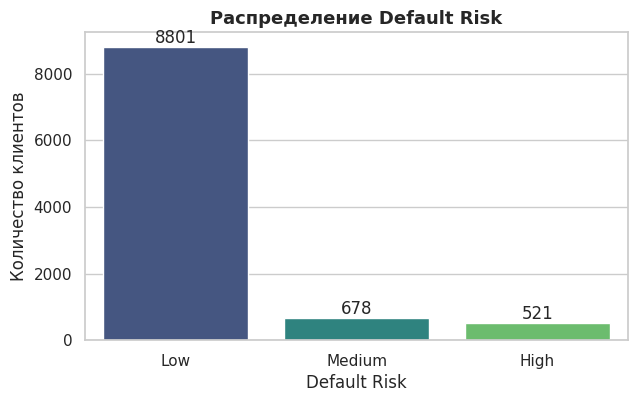

In [8]:
# График 1. Распределение уровней Default Risk
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Default_Risk', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Распределение Default Risk', fontsize=13, fontweight='bold')
plt.xlabel('Default Risk')
plt.ylabel('Количество клиентов')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.show()
# Вывод: неравномерное распределение целевой переменной

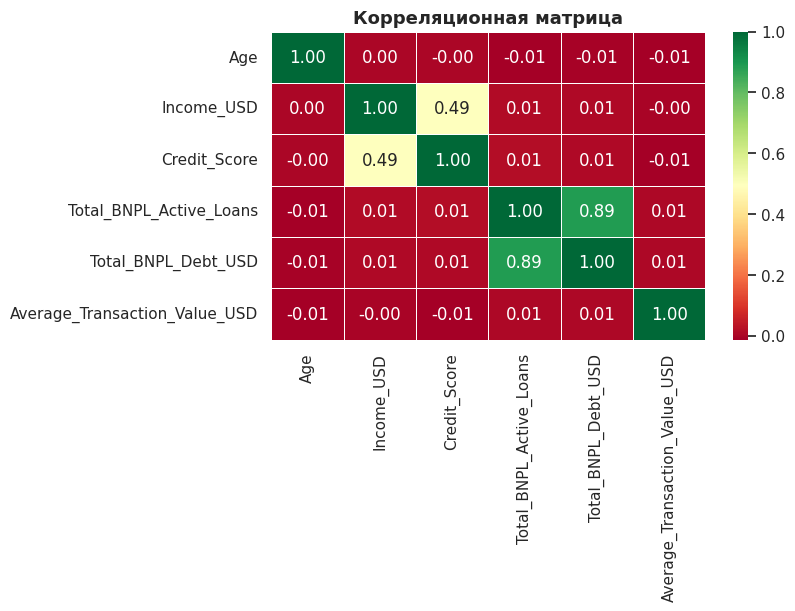

In [9]:
# График 2. Корреляционная матрица
plt.figure(figsize=(7, 4))
numerical_cols = ['Age', 'Income_USD', 'Credit_Score', 'Total_BNPL_Active_Loans',
                  'Total_BNPL_Debt_USD', 'Average_Transaction_Value_USD']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=13, fontweight='bold')
plt.show()
# Вывод: сильная корреляция между Total BNPL Active Loans и Total BNLP Debt USD - при увеличении одной переменной другая тоже увеличивается (логично)
# Слабая корреляция между Income и Credit Score

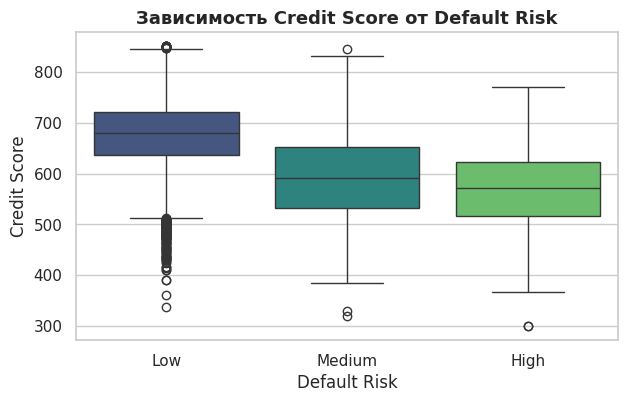

In [10]:
# График 3.Зависимость Credit Score от Default Risk
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Default_Risk', y='Credit_Score', palette='viridis')
plt.title('Зависимость Credit Score от Default Risk', fontsize=13, fontweight='bold')
plt.xlabel('Default Risk')
plt.ylabel('Credit Score')
plt.show()
# Вывод: чем выше Default Risk, тем ниже Credit Score.

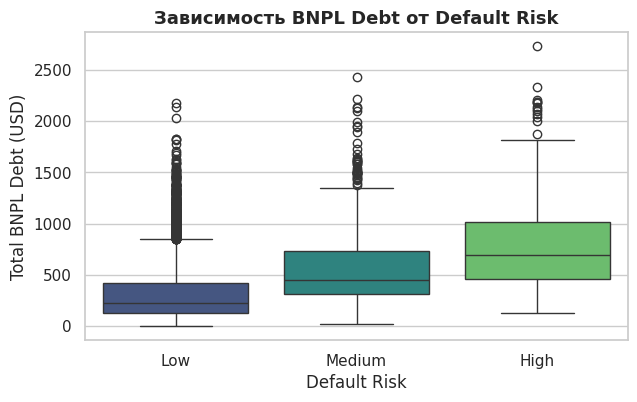

In [11]:
# График 4. Зависимость BNPL Debt от Default Risk
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Default_Risk', y='Total_BNPL_Debt_USD', palette='viridis')
plt.title('Зависимость BNPL Debt от Default Risk', fontsize=13, fontweight='bold')
plt.xlabel('Default Risk')
plt.ylabel('Total BNPL Debt (USD)')
plt.show()
# Вывод: медиана BNPL Debt (центральная линия внутри каждого ящика) увеличивается по мере роста уровни Default Risк.
# Выше уровень Default Risk, более широкий разброс значений  BNPL Debt, что указывает на большую вариативность в этих группах.

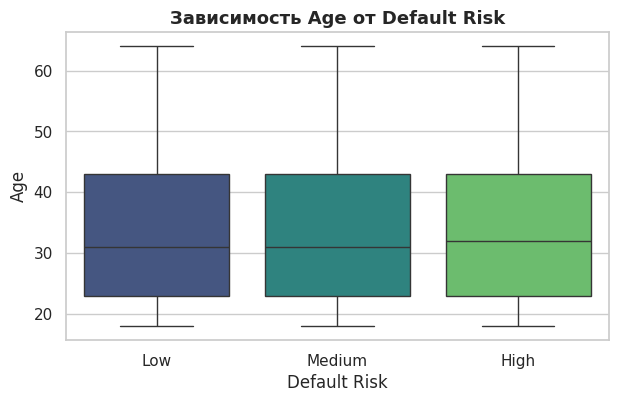

In [9]:
# График 5. Зависимость Age от Default Risk
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Default_Risk', y='Age', palette='viridis')
plt.title('Зависимость Age от Default Risk', fontsize=13, fontweight='bold')
plt.xlabel('Default Risk')
plt.ylabel('Age')
plt.show()
# Вывод: Возраст не является предиктом Default Risk

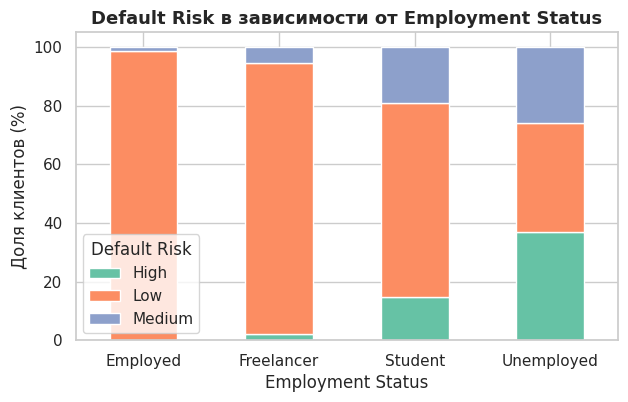

In [11]:
# График 6. Default Risk в зависимости от Employment Status.
employment_risk = pd.crosstab(df['Employment_Status'], df['Default_Risk'], normalize='index') * 100
employment_risk.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title('Default Risk в зависимости от Employment Status', fontsize=13, fontweight='bold')
plt.xlabel('Employment Status')
plt.ylabel('Доля клиентов (%)')
plt.legend(title='Default Risk')
plt.xticks(rotation=0)
plt.show()
# Вывод: Трудоустроенный имеет меньше уровень Default Risk чем безработный (логично)

In [13]:
# График 7. Зависимость Credit Score и BNPL Debt от Default Risk
fig = px.scatter(df, x='Credit_Score', y='Total_BNPL_Debt_USD', color='Default_Risk', size='Total_BNPL_Active_Loans',
    hover_data=['Age',
        'Income_USD',
        'Employment_Status',
        'Late_Payment_History',
        'Average_Transaction_Value_USD'],
    title='<b>Зависимость Credit Score и BNPL Debt от Default Risk</b>',
    labels={
        'Credit_Score': 'Credit Score',
        'Total_BNPL_Debt_USD': 'BNPL Debt (USD)',
        'Default_Risk': 'Default Risk',
        'Total_BNPL_Active_Loans': 'Active BNPL Loans'})
fig.show()
# Вывод:
# Размер каждой точки соответствует количеству активных BNPL кредитов (Total BNPL Active Loans).
# Как правило, клиенты с низким риском дефолта (Low Default Risk) имеют более высокий Credit Score и меньший Total BNPL Debt.
# По мере увеличения риска дефолта (Medium, High), мы наблюдаем тенденцию к снижению Credit Score и увеличению Total BNPL Debt.
# Также можно заметить, что клиенты с большим количеством активных BNPL кредитов (крупные точки) могут быть более склонны к более высокому риску дефолта и большему долгу.

## **РАЗДЕЛ 2. Предобработка и baseline  модель**


Accuracy: 0.8785

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.83      0.82       104
         Low       0.99      0.89      0.94      1760
      Medium       0.33      0.78      0.47       136

    accuracy                           0.88      2000
   macro avg       0.71      0.83      0.74      2000
weighted avg       0.94      0.88      0.90      2000



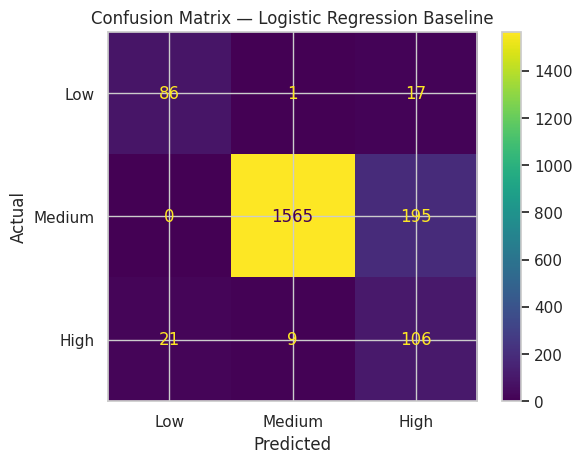

In [21]:
# Разделяем признаки и целевую переменную
X = df.drop(columns=['Customer_ID', 'Default_Risk'])
y = df['Default_Risk']

# Определяем числовые признаки
numeric_features = [
    'Age',
    'Income_USD',
    'Credit_Score',
    'Total_BNPL_Active_Loans',
    'Total_BNPL_Debt_USD',
    'Average_Transaction_Value_USD']

# Определяем категориальные признаки
categorical_features = [
    'Employment_Status',
    'Late_Payment_History',
    'Shopping_Category_Most_Frequent']

# Делим данные на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

# Предобработка числовых признаков
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())])

# Предобработка категориальных признаков
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False))])

# Объединяем preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)])

# Logistic Regression
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42))])

# Обучаем модель
baseline_model.fit(X_train, y_train)

# Делаем предсказания
y_pred = baseline_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High'])
disp.plot()
plt.title('Confusion Matrix — Logistic Regression Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Вывод:
Medium: precision 0.33, recall 0.78, F1 = 0.47 — главная проблема модели.
Несмотря на то, что Accuracy = 87.85% это не означает, что модель отличная потому что у нас сильный дисбаланс классов:
Low — 88.01%
Medium — 6.78%
High — 5.21%
Поэтому модель может иметь высокую Accuracy просто за счёт хорошего распознавания Low.
А вот Macro F1 = 0.74 гораздо лучше отражает качество по всем трём классам.
Особенно интересно, что модель достаточно хорошо находит клиентов Medium (recall 0.78), но при этом precision всего 0.33. То есть модель часто говорит «Medium», когда настоящий класс другой.

# **РАЗДЕЛ 3. Улучшенная модель**

Лучшие параметры:
{'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Лучший F1-macro на Cross-Validation:
0.8048

Accuracy:
0.92
              precision    recall  f1-score   support

        High       0.73      0.80      0.76       104
         Low       0.99      0.95      0.97      1760
      Medium       0.45      0.62      0.52       136

    accuracy                           0.92      2000
   macro avg       0.72      0.79      0.75      2000
weighted avg       0.94      0.92      0.93      2000



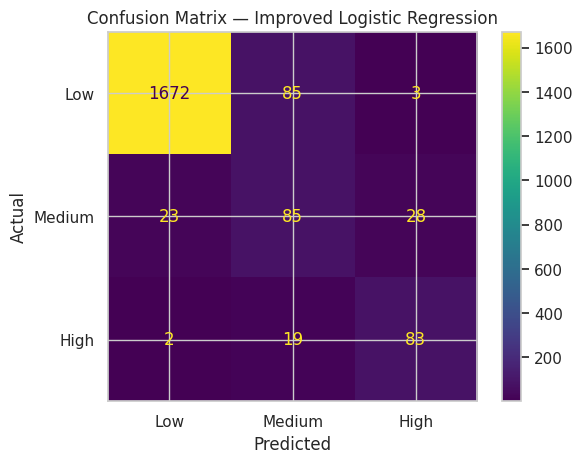

In [22]:
# GridSearchCV для Logistic Regression
# Создаём модель для GridSearchCV
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42)

#  Создаём Pipeline
grid_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logreg)])

# Задаём параметры для перебора
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__penalty': ['l2']}

# Создаём GridSearchCV
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1)

# Обучаем GridSearchCV
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:")
print(grid_search.best_params_)

# Лучший результат на кросс-валидации
print("\nЛучший F1-macro на Cross-Validation:")
print(round(grid_search.best_score_, 4))

# Предсказания лучшей модели
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test)

# Оценка на Test
print("\nAccuracy:")
print(round(accuracy_score(y_test, y_pred_grid), 4))
print(classification_report(y_test, y_pred_grid))

# Confusion Matrix
cm_grid = confusion_matrix(
    y_test,
    y_pred_grid,
    labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_grid,
    display_labels=['Low', 'Medium', 'High'])
disp.plot()
plt.title('Confusion Matrix — Improved Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# Вывод:
# Accuracy выросла с 87.85% до 92%, а Medium немного улучшился: F1 с 0.47 → 0.52.
# Но High ухудшился с 0.82 → 0.76. Для задачи оценки риска это нельзя игнорировать, потому что именно High может быть наиболее важным классом с точки зрения бизнеса.

Новый признак Debt_to_Income:
count    10000.000000
mean         0.011992
std          0.021198
min          0.000000
25%          0.002371
50%          0.005362
75%          0.012205
max          0.423400
Name: Debt_to_Income, dtype: float64

Accuracy:
0.951
              precision    recall  f1-score   support

        High       0.84      0.93      0.88       104
         Low       0.99      0.97      0.98      1760
      Medium       0.62      0.74      0.68       136

    accuracy                           0.95      2000
   macro avg       0.82      0.88      0.85      2000
weighted avg       0.96      0.95      0.95      2000



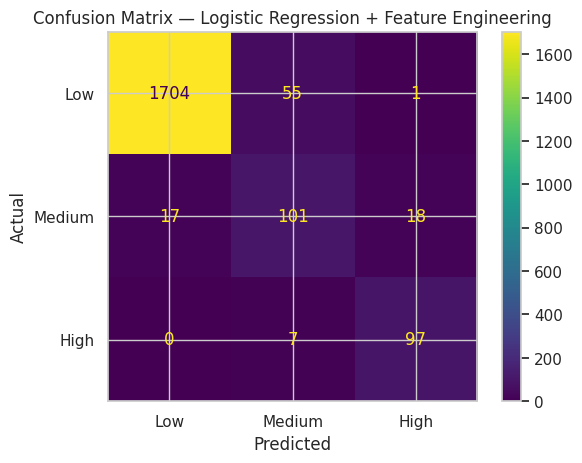

In [23]:
# FEATURE ENGINEERING
# Создаём независимую копию исходного датасета
df_fe = df.copy()

# Создаём новый признак Debt-to-Income, который гораздо информативнее чем Total BNLP Debt и Income по отдельности
df_fe['Debt_to_Income'] = (df_fe['Total_BNPL_Debt_USD'] / df_fe['Income_USD'])

# Проверяем новый признак
print("Новый признак Debt_to_Income:")
print(df_fe['Debt_to_Income'].describe())

# X и y
X_fe = df_fe.drop(['Customer_ID','Default_Risk'], axis=1)
y_fe = df_fe['Default_Risk']

#  Числовые признаки
numeric_features_fe = [
    'Age',
    'Income_USD',
    'Credit_Score',
    'Total_BNPL_Active_Loans',
    'Total_BNPL_Debt_USD',
    'Average_Transaction_Value_USD',
    'Debt_to_Income']

# Категориальные признаки
categorical_features_fe = [
    'Employment_Status',
    'Late_Payment_History',
    'Shopping_Category_Most_Frequent']

# Train / Test Split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe)

#  Preprocessing
numeric_pipeline_fe = Pipeline([('scaler', StandardScaler())])
categorical_pipeline_fe = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False))])
preprocessor_fe = ColumnTransformer([
    ('num', numeric_pipeline_fe, numeric_features_fe),
    ('cat', categorical_pipeline_fe, categorical_features_fe)])

# Logistic Regression c лучшими параметрами из GridSearchCV
feature_model = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(
        C=100,
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42))])

# Обучение
feature_model.fit(X_train_fe, y_train_fe)

# Предсказания
y_pred_fe = feature_model.predict(X_test_fe)

# Оценка
print("\nAccuracy:")
print(round(accuracy_score(y_test_fe, y_pred_fe), 4))
print(classification_report(y_test_fe, y_pred_fe))

# Confusion Matrix
cm_fe = confusion_matrix(
    y_test_fe,
    y_pred_fe,
    labels=['Low', 'Medium', 'High'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_fe,
    display_labels=['Low', 'Medium', 'High'])
disp.plot()
plt.title('Confusion Matrix — Logistic Regression + Feature Engineering')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Accuracy:
0.9595
              precision    recall  f1-score   support

        High       0.87      0.90      0.89       104
         Low       0.98      0.99      0.98      1760
      Medium       0.74      0.63      0.68       136

    accuracy                           0.96      2000
   macro avg       0.86      0.84      0.85      2000
weighted avg       0.96      0.96      0.96      2000



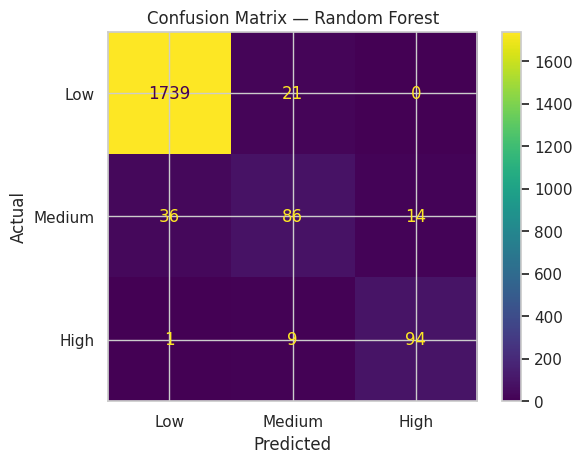

In [24]:
# RANDOM FOREST
# Используем копию с Feature Engineering
X_rf = df_fe.drop(['Customer_ID', 'Default_Risk'], axis=1)
y_rf = df_fe['Default_Risk']

# Train / Test Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf)

#  Preprocessing
categorical_pipeline_rf = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False))])

preprocessor_rf = ColumnTransformer([
    ('cat', categorical_pipeline_rf, categorical_features_fe)
], remainder='passthrough')

# Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1))])

# Обучение
rf_model.fit(X_train_rf, y_train_rf)

# Предсказания
y_pred_rf = rf_model.predict(X_test_rf)

# Оценка
print("\nAccuracy:")
print(round(accuracy_score(y_test_rf, y_pred_rf), 4))
print(classification_report(y_test_rf, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(
    y_test_rf,
    y_pred_rf,
    labels=(['Low', 'Medium', 'High']))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Low', 'Medium', 'High'])
disp.plot()
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Лучшие параметры:
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Лучший F1-macro на Cross-Validation:
0.8929

Лучшая модель:

Accuracy:
0.96

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.88      0.87       104
         Low       0.99      0.98      0.98      1760
      Medium       0.69      0.75      0.72       136

    accuracy                           0.96      2000
   macro avg       0.84      0.87      0.86      2000
weighted avg       0.96      0.96      0.96      2000



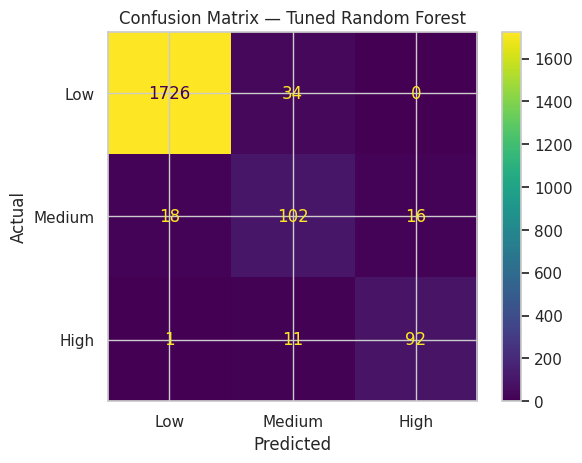

In [26]:
# GRIDSEARCHCV — RANDOM FOREST
# Базовый Random Forest
rf_for_grid = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

# Pipeline
rf_grid_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', rf_for_grid)])

# Параметры для подбора
param_grid_rf = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']}

# GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1)

# Обучение
rf_grid_search.fit(X_train_rf, y_train_rf)

# Лучшие параметры
print("\nЛучшие параметры:")
print(rf_grid_search.best_params_)

# Лучший F1 Macro на Cross-Validation
print("\nЛучший F1-macro на Cross-Validation:")
print(round(rf_grid_search.best_score_, 4))

# Лучшая модель
print("\nЛучшая модель:")
best_rf_model = rf_grid_search.best_estimator_

# Предсказания
y_pred_rf_grid = best_rf_model.predict(X_test_rf)

# Accuracy
print("\nAccuracy:")
print(round(accuracy_score(y_test_rf, y_pred_rf_grid), 4))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf_grid))

# Confusion Matrix
cm_rf_grid = confusion_matrix(
    y_test_rf,
    y_pred_rf_grid,
    labels=['Low', 'Medium', 'High'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_grid,
    display_labels=['Low', 'Medium', 'High'])

disp.plot()
plt.title('Confusion Matrix — Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Accuracy:
0.963
              precision    recall  f1-score   support

        High       0.88      0.92      0.90       104
         Low       0.99      0.98      0.98      1760
      Medium       0.71      0.78      0.74       136

    accuracy                           0.96      2000
   macro avg       0.86      0.89      0.88      2000
weighted avg       0.97      0.96      0.96      2000



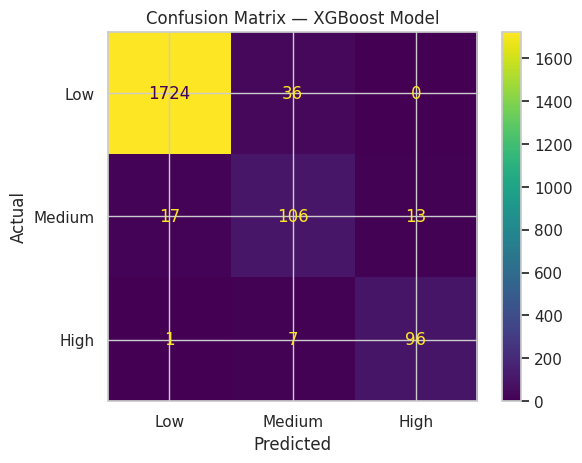

In [25]:
# XGBOOST
# Кодирование целевой переменной
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_rf)
y_test_encoded = le.transform(y_test_rf)

# Расчет весов классов для обработки дисбаланса (используем закодированные метки)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded)

# Создаем словарь отображения закодированного класса на его вес
weights_dict_encoded = {cls_label: weight for cls_label, weight in zip(np.unique(y_train_encoded), class_weights)}

# Создаем веса для каждого образца в y_train_rf, используя закодированные метки
sample_weights = np.array([weights_dict_encoded[label] for label in y_train_encoded])

# Определяем модель XGBoost
xgb_model_base = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train_encoded)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1)

# Pipeline с препроцессором (используем preprocessor_rf из Random Forest секции)
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', xgb_model_base)])

# Обучение модели с использованием sample_weights и закодированных меток
xgb_pipeline.fit(X_train_rf, y_train_encoded, model__sample_weight=sample_weights)

# Предсказания (модель предсказывает закодированные метки)
y_pred_xgb_encoded = xgb_pipeline.predict(X_test_rf)

# Декодируем предсказания обратно в строковые метки для отчета
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

# Оценка (используем исходные y_test_rf для сравнения с предсказанными строковыми метками)
print("\nAccuracy:")
print(round(accuracy_score(y_test_rf, y_pred_xgb), 4))
print(classification_report(y_test_rf, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(
    y_test_rf,
    y_pred_xgb,
    labels=['Low', 'Medium', 'High'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Low', 'Medium', 'High'])
disp.plot()
plt.title('Confusion Matrix — XGBoost Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **РАЗДЕЛ 4. Сравнение метрик baseline и улучшенной модели**

In [27]:
from sklearn.metrics import classification_report
import json

results = {}

# 1. Baseline Logistic Regression
y_pred_baseline = baseline_model.predict(X_test)
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True)
results['Logistic Regression Baseline'] = {
    'Accuracy': report_baseline['accuracy'],
    'F1 Macro': report_baseline['macro avg']['f1-score'],
    'F1 High': report_baseline['High']['f1-score'],
    'F1 Medium': report_baseline['Medium']['f1-score'],
    'F1 Low': report_baseline['Low']['f1-score']
}

# 2. GridSearch Logistic Regression
y_pred_grid_lr = best_model.predict(X_test)
report_grid_lr = classification_report(y_test, y_pred_grid_lr, output_dict=True)
results['GridSearch Logistic Regression'] = {
    'Accuracy': report_grid_lr['accuracy'],
    'F1 Macro': report_grid_lr['macro avg']['f1-score'],
    'F1 High': report_grid_lr['High']['f1-score'],
    'F1 Medium': report_grid_lr['Medium']['f1-score'],
    'F1 Low': report_grid_lr['Low']['f1-score']
}

# 3. Feature Engineering Logistic Regression
y_pred_fe = feature_model.predict(X_test_fe)
report_fe = classification_report(y_test_fe, y_pred_fe, output_dict=True)
results['Logistic Regression (+FE)'] = {
    'Accuracy': report_fe['accuracy'],
    'F1 Macro': report_fe['macro avg']['f1-score'],
    'F1 High': report_fe['High']['f1-score'],
    'F1 Medium': report_fe['Medium']['f1-score'],
    'F1 Low': report_fe['Low']['f1-score']
}

# 4. Random Forest
y_pred_rf_base = rf_model.predict(X_test_rf)
report_rf_base = classification_report(y_test_rf, y_pred_rf_base, output_dict=True)
results['Random Forest Baseline'] = {
    'Accuracy': report_rf_base['accuracy'],
    'F1 Macro': report_rf_base['macro avg']['f1-score'],
    'F1 High': report_rf_base['High']['f1-score'],
    'F1 Medium': report_rf_base['Medium']['f1-score'],
    'F1 Low': report_rf_base['Low']['f1-score']
}

# 5. Grid Search Random Forest
y_pred_rf_grid = best_rf_model.predict(X_test_rf)
report_rf_grid = classification_report(y_test_rf, y_pred_rf_grid, output_dict=True)
results['Grid Search Random Forest'] = {
    'Accuracy': report_rf_grid['accuracy'],
    'F1 Macro': report_rf_grid['macro avg']['f1-score'],
    'F1 High': report_rf_grid['High']['f1-score'],
    'F1 Medium': report_rf_grid['Medium']['f1-score'],
    'F1 Low': report_rf_grid['Low']['f1-score']
}

# 6. XGBoost
y_pred_xgb_encoded = xgb_pipeline.predict(X_test_rf)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)
report_xgb = classification_report(y_test_rf, y_pred_xgb, output_dict=True)
results['XGBoost'] = {
    'Accuracy': report_xgb['accuracy'],
    'F1 Macro': report_xgb['macro avg']['f1-score'],
    'F1 High': report_xgb['High']['f1-score'],
    'F1 Medium': report_xgb['Medium']['f1-score'],
    'F1 Low': report_xgb['Low']['f1-score']
}

# Convert to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')

print('Сводная таблица результатов моделей:')
print(results_df.round(4))


Сводная таблица результатов моделей:
                                Accuracy  F1 Macro  F1 High  F1 Medium  F1 Low
Logistic Regression Baseline      0.8785    0.7402   0.8152     0.4670  0.9385
GridSearch Logistic Regression    0.9200    0.7506   0.7615     0.5231  0.9673
Logistic Regression (+FE)         0.9510    0.8455   0.8818     0.6756  0.9790
Random Forest Baseline            0.9595    0.8510   0.8868     0.6825  0.9836
Grid Search Random Forest         0.9600    0.8579   0.8679     0.7208  0.9849
XGBoost                           0.9630    0.8766   0.9014     0.7439  0.9846
